In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/sonamu/final_project/data/2019-Oct_sample_1_5GB.csv")


In [2]:
# 지수 -> 소수점(2) 표기
pd.options.display.float_format = '{:.2f}'.format

In [3]:
print(df.head())
print(df.info())
print(df.shape)

                event_time event_type  product_id          category_id  \
0  2019-10-01 04:49:23 UTC       view     1004957  2053013555631882655   
1  2019-10-01 03:58:42 UTC       view    26402232  2053013563651392361   
2  2019-10-01 05:28:41 UTC       view    26403381  2053013563651392361   
3  2019-10-01 03:51:05 UTC       view    10201532  2053013553224352013   
4  2019-10-01 03:07:56 UTC       view    17900150  2053013560178508465   

                  category_code    brand   price    user_id  \
0        electronics.smartphone   xiaomi  348.53  518613790   
1                           NaN      NaN  467.12  555300468   
2                           NaN      NaN   95.76  514114758   
3                    kids.dolls  llorens   60.46  536806958   
4  construction.tools.generator    senci 1021.33  543027553   

                           user_session  
0  93141b24-e95e-4c4b-8796-33141a727fb5  
1  d531c1aa-5461-40eb-b5dd-6507ab023664  
2  5dd0b291-09c6-44b2-b8de-002bdf918134  
3  1e386

In [4]:
print(df.columns.tolist())

['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12060967 entries, 0 to 12060966
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 1.8 GB


### 전처리 계획
- event_time : 날짜로 타입 변환 필요 -> pd.to_datetime()
    - 2019-10-01 04:49:23 UTC < 이런 형식이므로 '%Y-%m-%d %H:%M:%S' UTC?
- category_code : telephone, smartphone 혼용. '.' 사용되어 split 필요
    - 왜 혼용되었는가? 
        - 1. 과거 / 현재 (날짜 찍어보면 될 것 같음) ㅠㅠ 교육데이터에게 데인 기억이 (조사 필요)
        - 2. 아예 다른 제품군이거나, 아니면 카테고리명 변경이거나 로그 데이터라 카테고리명이 변경되었을 가능성 있음
        

### 결측치
- category_code (3840432)
    - 근거 : 결측치 패턴 찾아야 할 것 같음
- brand (1737224)
    - 근거 : 브랜드가 없는 제품(소규모 마켓)일 가능성. 확인 필요

In [6]:
df['price'].describe()

count   12060967.00
mean         290.28
std          358.16
min            0.00
25%           65.90
50%          162.93
75%          358.57
max         2574.07
Name: price, dtype: float64

In [7]:
df.isna().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3840432
brand            1737224
price                  0
user_id                0
user_session           1
dtype: int64

In [8]:
df.isna().mean() * 100

event_time       0.00
event_type       0.00
product_id       0.00
category_id      0.00
category_code   31.84
brand           14.40
price            0.00
user_id          0.00
user_session     0.00
dtype: float64

In [9]:
df.duplicated().sum()

# 중복값 있긴 한데 근거 필요 진짜 제거 가능한건지 drop 해도 되는지

np.int64(3648)

In [10]:
df.nunique()

event_time       2390513
event_type             3
product_id        148389
category_id          620
category_code        126
brand               3316
price              57419
user_id          2121344
user_session     5331915
dtype: int64

In [11]:
df['user_session'].unique

<bound method Series.unique of 0           93141b24-e95e-4c4b-8796-33141a727fb5
1           d531c1aa-5461-40eb-b5dd-6507ab023664
2           5dd0b291-09c6-44b2-b8de-002bdf918134
3           1e38622f-52d6-41fd-beac-dac9d242d378
4           a6fba805-3f87-4f1f-8b9a-2e77776a22e5
                            ...                 
12060962    a94f4907-3882-4ee8-b197-6e243ff68bcc
12060963    8bbe7e1e-0d69-4eaa-8c75-68fd222d45a5
12060964    3871a6b4-7215-45a5-968f-3e10d5c49db6
12060965    29fed5f4-ef51-41ca-a722-8133d1980bd1
12060966    27c1dfc2-fde9-4f24-ae2b-7e899139867a
Name: user_session, Length: 12060967, dtype: str>

In [12]:
df['event_type'].unique()

<ArrowStringArray>
['view', 'purchase', 'cart']
Length: 3, dtype: str

In [13]:
df['category_code'].unique()

<ArrowStringArray>
[      'electronics.smartphone',                            nan,
                   'kids.dolls', 'construction.tools.generator',
     'computers.components.hdd',    'appliances.kitchen.washer',
  'electronics.audio.subwoofer',        'electronics.telephone',
           'computers.notebook',         'electronics.video.tv',
 ...
                'apparel.dress',    'apparel.shoes.espadrilles',
                 'apparel.sock',               'apparel.shorts',
                'apparel.skirt', 'country_yard.furniture.bench',
   'appliances.environment.fan', 'construction.tools.soldering',
               'apparel.jumper', 'auto.accessories.anti_freeze']
Length: 127, dtype: str

In [14]:
df[~df['category_code'].isna()].head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 04:49:23 UTC,view,1004957,2053013555631882655,electronics.smartphone,xiaomi,348.53,518613790,93141b24-e95e-4c4b-8796-33141a727fb5
3,2019-10-01 03:51:05 UTC,view,10201532,2053013553224352013,kids.dolls,llorens,60.46,536806958,1e38622f-52d6-41fd-beac-dac9d242d378
4,2019-10-01 03:07:56 UTC,view,17900150,2053013560178508465,construction.tools.generator,senci,1021.33,543027553,a6fba805-3f87-4f1f-8b9a-2e77776a22e5
6,2019-10-01 05:06:23 UTC,view,6800005,2053013554222596431,computers.components.hdd,transcend,409.15,514444074,8deb2ed1-3de4-4518-8454-18237e21d4e3
7,2019-10-01 05:45:32 UTC,view,3601427,2053013563810775923,appliances.kitchen.washer,lg,336.95,525289779,f40f510f-c492-4ca4-9615-2e84f1acf910
8,2019-10-01 05:03:53 UTC,view,5801218,2053013553945772349,electronics.audio.subwoofer,NaN,43.73,515846175,c4703bf2-5368-43ee-91bb-c4b1f6e40cda
11,2019-10-01 05:13:28 UTC,view,8800859,2053013555573162395,electronics.telephone,bq,32.15,540852415,28dba4f2-64fc-47a0-b1eb-28e0c1d5a1a6
13,2019-10-01 04:12:07 UTC,view,1306613,2053013558920217191,computers.notebook,xiaomi,1518.44,524309914,1e5a3e74-a2b8-408d-bbbf-3321db566746
15,2019-10-01 04:39:54 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.76,538796288,16bb75c5-0067-47f8-b303-492814bc0a53
17,2019-10-01 05:50:12 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.76,534491343,60639aa5-6b6e-4a8a-8187-9061da9c2be4


<Axes: xlabel='price'>

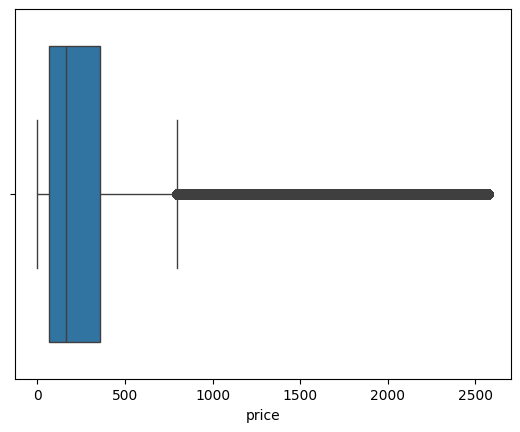

In [15]:
sns.boxplot(x=df['price'])

In [16]:
df['event_type'].value_counts()

event_type
view        11586901
cart          263053
purchase      211013
Name: count, dtype: int64

In [17]:
df['brand'].value_counts()

brand
samsung        1500811
apple          1171703
xiaomi          876343
huawei          316051
lucente         186809
                ...   
dobroparov           1
kafekrasoty          1
vorson               1
aquarelle            1
milk                 1
Name: count, Length: 3316, dtype: int64

In [18]:
df['event_time'].head()

0    2019-10-01 04:49:23 UTC
1    2019-10-01 03:58:42 UTC
2    2019-10-01 05:28:41 UTC
3    2019-10-01 03:51:05 UTC
4    2019-10-01 03:07:56 UTC
Name: event_time, dtype: str

In [19]:
# 날짜 (to_datetime)

df['event_time'] = pd.to_datetime(df['event_time'], format='%Y-%m-%d %H:%M:%S UTC', errors='coerce')

# UTC? 안 쓰면 오류

In [20]:
# sns.lineplot(x=df[''])

<Axes: xlabel='event_time'>

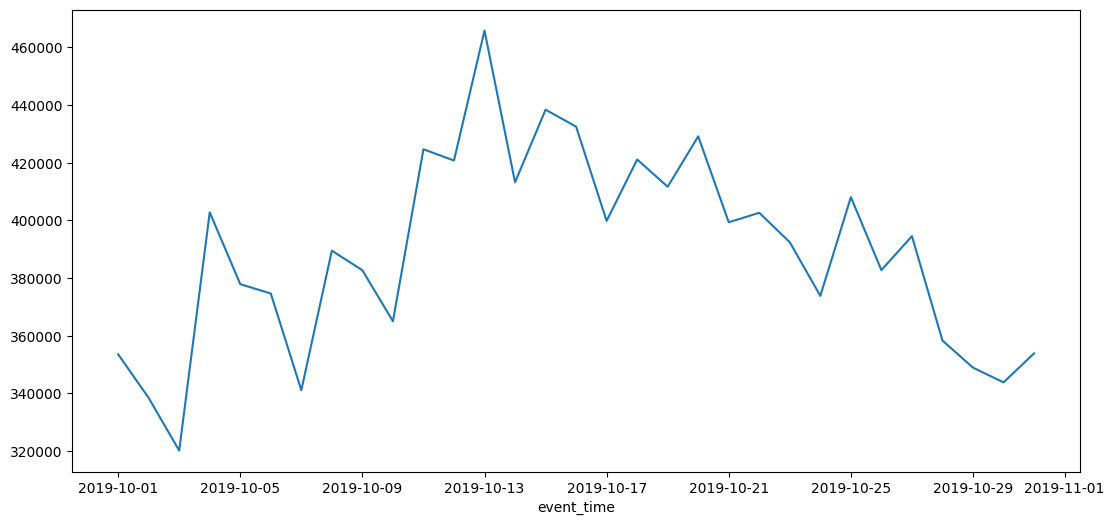

In [21]:
df.groupby(df['event_time'].dt.date).size().plot(kind='line', figsize=(13, 6))

# 와 태블로 마렵다 라벨링

event_type
view        11586901
cart          263053
purchase      211013
Name: count, dtype: int64
event_type
view       96.07
cart        2.18
purchase    1.75
Name: proportion, dtype: float64


<Axes: xlabel='event_type'>

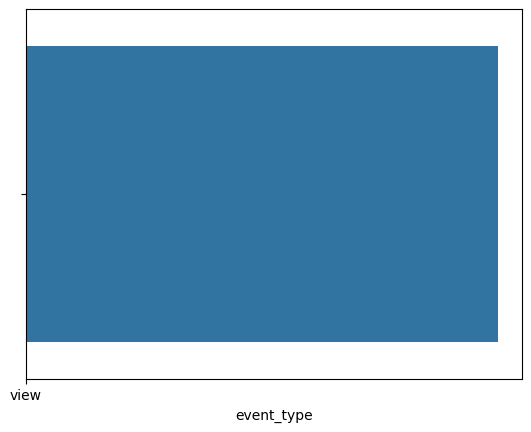

In [22]:
print(df['event_type'].value_counts())
print(df['event_type'].value_counts(normalize=True) * 100)
sns.barplot(data=df, x="event_type", errorbar=None)

# 너무 커서 안 보이는 것 같다...

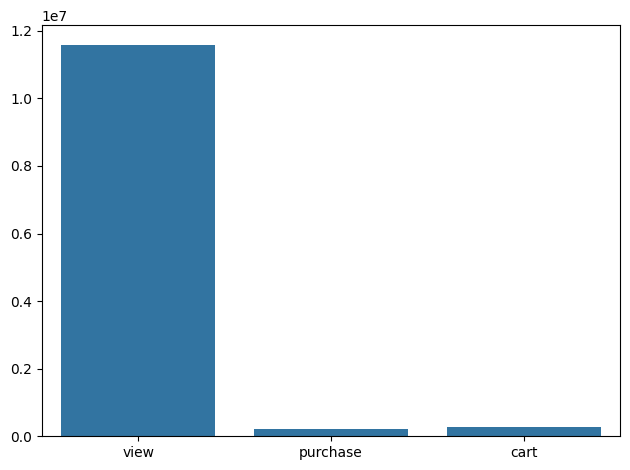

In [23]:
sns.countplot(data=df, x="event_type")

plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [24]:
#### sns.scatterplot(data=df, x="event_time", y="price")

# df.plot(kind='scatter', x='event_time', y='price')

# 어엉 넘 커서그런가 

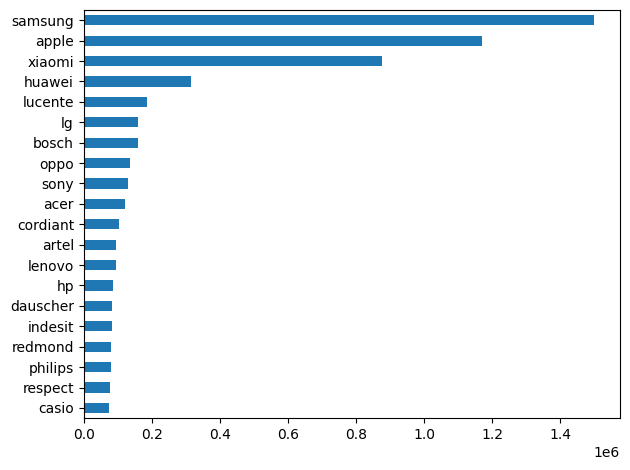

In [25]:
# sns.countplot(data=df, x="high_brands", order=order)

high_brands = df['brand'].value_counts().head(20)
order = df['brand'].value_counts().index

high_brands.sort_values().plot(kind='barh')

plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 음 너무 많아서

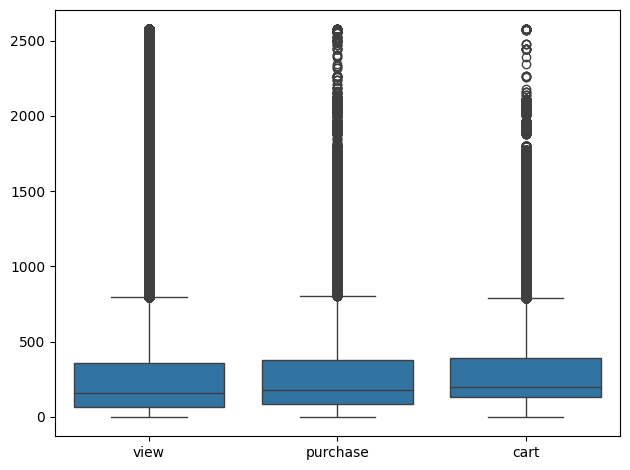

In [26]:
sns.boxplot(data=df, x='event_type', y='price')

plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 허허;; 이상치보소

# 하긴 가구니까 특정 상품은 되게 비싸고 중저가도 있는데 아무래도 비쌀 것 같긴 함 가구니까 
# 전자제품부터 대형 막 거대한 가구도 있으니까 
# 이건 나중에 phone으로 자르고 다시 뽑아봐야할듯?

### 오늘의 전처리 결론
- event_time 날짜 타입 변환 완료
- phone인 걸 보려면 split으로 '.' 먼저 자르고 phone 분류 두개 합치고 그걸로 다시 봐야 한다 (파생변수)
- 근거 필요 : 
    - 중복값 : duplicated(3648) 
    - 결측치 : 
        - category_code (3840432) : 어떤 애들이 없는지 확인 필요(패턴)
        - brand (1737224) : 자사 브랜드 없는 소규모... 마켓 제품...이 아닐까? 조사 필요
    - view, cart, purchase 정확하게 의미 파악
    - price 이상치 (아마 이건 근데 phone 분류 다시 생성하고 봐야 해서)

- 데이터 딕셔너리 업데이트(결측치 비율, 데이터 타입 등)
- 컬럼이 적어서 파생변수 설정이 중요할 듯? 사용자 행동 패턴을 설명할 수 있는 컬럼을 어떤 근거로 만드느냐 <